# Proyecto Final - Predicción del Rendimiento Académico (EduPath AI)

## Objetivo
Desarrollar y comparar modelos de aprendizaje automático para predecir el GPA de estudiantes a partir de variables demográficas, familiares y académicas.

## Metodología
1. Carga y exploración de datos.
2. Análisis exploratorio (EDA).
3. Preprocesamiento.
4. Entrenamiento de modelos:
   - Regresión Lineal
   - Random Forest
   - XGBoost
   - Red Neuronal
5. Evaluación mediante MAE, RMSE y R².
6. Selección del modelo con mejor capacidad de generalización.

## Conclusión esperada
Seleccionar el modelo con mejor desempeño sobre el conjunto de prueba para integrarlo en EduPath AI.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10,6)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [6]:
# Ruta al archivo
ruta = "/Users/alegomez/Library/CloudStorage/OneDrive-UniversidadAutónomadelEstadodeMéxico/CIENCIA DE DATOS/Módulo 5/Student_performance_data.csv"

# Cargar el dataset
df = pd.read_csv(ruta)

print("Dimensión del dataset:", df.shape)
display(df.head())

Dimensión del dataset: (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001.0,17.0,1.0,0.0,2.0,19.833723,7.0,1.0,2.0,0.0,0.0,1.0,0.0,2.929196,2.0
1,1002.0,18.0,0.0,0.0,1.0,15.408756,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.042915,1.0
2,1003.0,15.0,0.0,2.0,3.0,4.210570,26.0,0.0,2.0,0.0,0.0,0.0,0.0,0.112602,4.0
3,1004.0,17.0,1.0,0.0,3.0,10.028829,14.0,0.0,3.0,1.0,0.0,0.0,0.0,2.054218,3.0
4,1005.0,17.0,1.0,0.0,2.0,4.672495,17.0,1.0,3.0,0.0,0.0,0.0,0.0,1.288061,4.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   float64
 1   Age                2392 non-null   float64
 2   Gender             2392 non-null   float64
 3   Ethnicity          2392 non-null   float64
 4   ParentalEducation  2392 non-null   float64
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   float64
 7   Tutoring           2392 non-null   float64
 8   ParentalSupport    2392 non-null   float64
 9   Extracurricular    2392 non-null   float64
 10  Sports             2392 non-null   float64
 11  Music              2392 non-null   float64
 12  Volunteering       2392 non-null   float64
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(15)
memory usage: 280.4 KB


In [8]:
df["Gender"] = df["Gender"].astype(int)

El conjunto de datos contiene 2,392 registros y 15 variables relacionadas con características demográficas, hábitos de estudio, apoyo familiar y desempeño académico. Durante la revisión inicial se observó que todas las variables cuentan con la totalidad de sus registros, por lo que el dataset no presenta valores faltantes. Asimismo, los datos fueron importados correctamente y se encuentran listos para iniciar el análisis exploratorio. Aunque todas las variables fueron leídas como tipo float64, algunas corresponden a variables categóricas binarias, las cuales podrán convertirse posteriormente al tipo entero para facilitar su interpretación y modelado.

In [9]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


Edad: 

El dataset representa estudiantes de educación media superior (aproximadamente preparatoria), ya que las edades se concentran entre los 15 y 18 años.




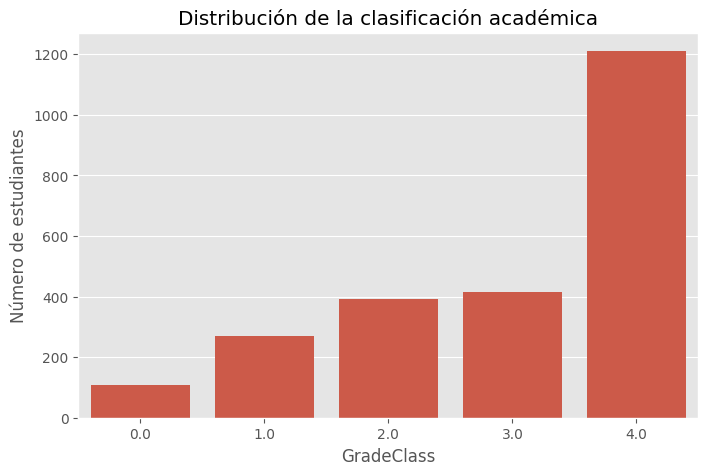

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="GradeClass")

plt.title("Distribución de la clasificación académica")
plt.xlabel("GradeClass")
plt.ylabel("Número de estudiantes")

plt.show()

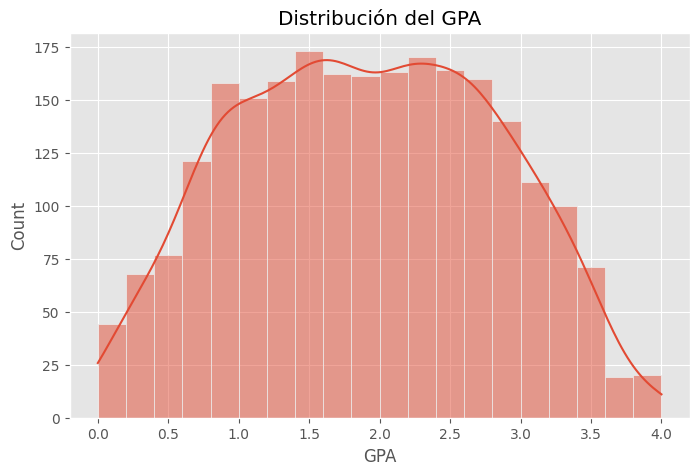

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["GPA"], bins=20, kde=True)

plt.title("Distribución del GPA")
plt.xlabel("GPA")

plt.show()

La distribución de la variable GradeClass muestra un claro desbalance entre las categorías. La clase 4 concentra la mayor cantidad de estudiantes, mientras que la clase 0 presenta una frecuencia considerablemente menor. Este comportamiento deberá considerarse durante la etapa de modelado para evitar sesgos hacia la clase mayoritaria.

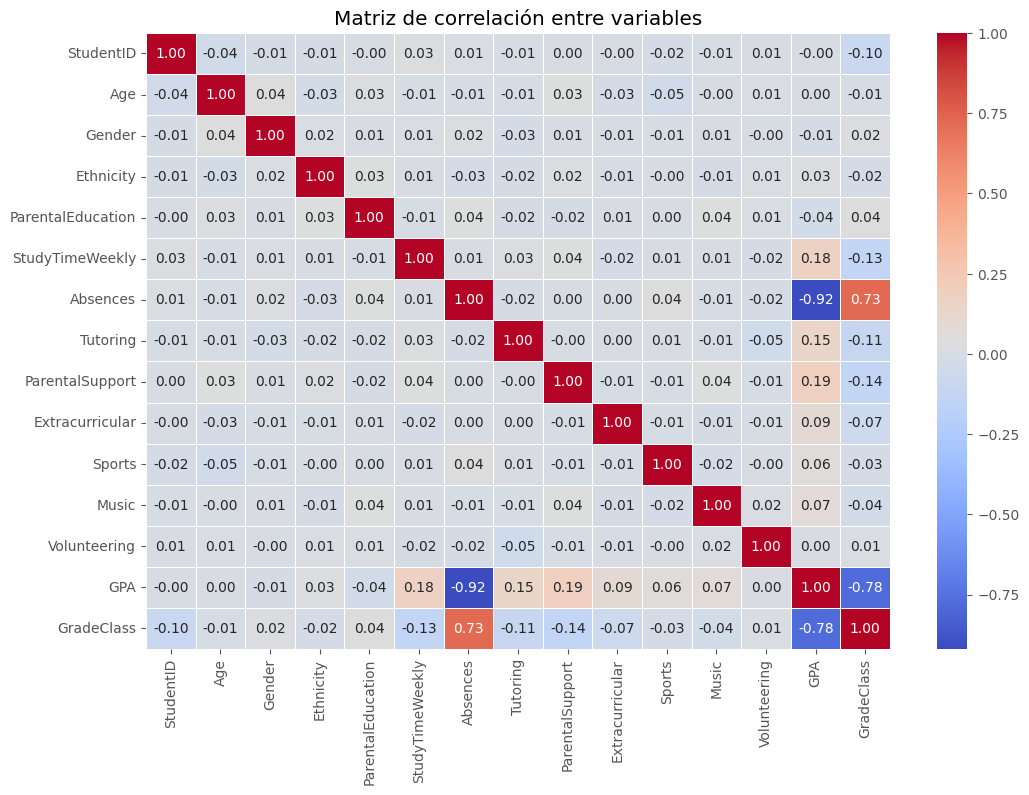

In [12]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables")

plt.show()

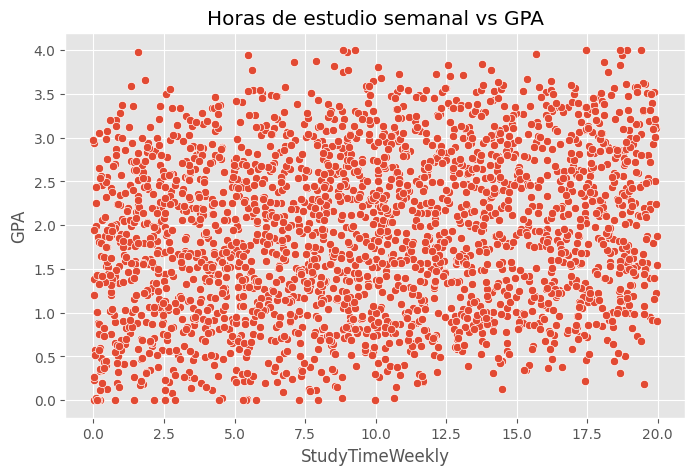

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="StudyTimeWeekly",
    y="GPA"
)

plt.title("Horas de estudio semanal vs GPA")

plt.show()

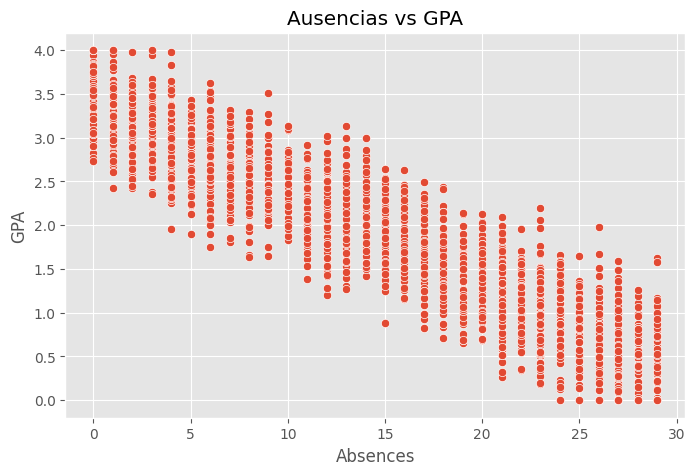

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Absences",
    y="GPA"
)

plt.title("Ausencias vs GPA")

plt.show()

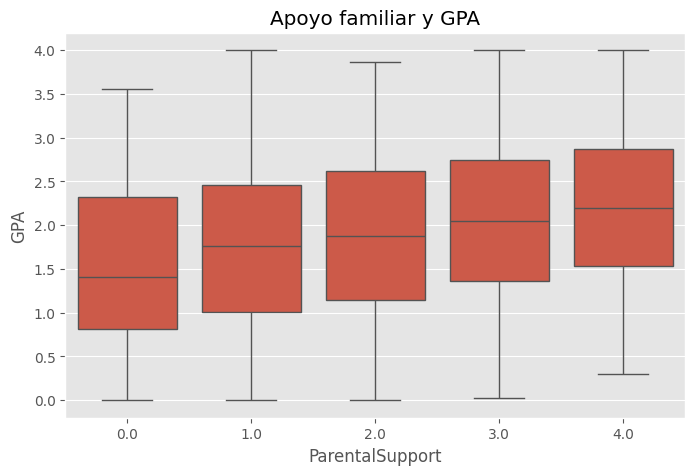

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="ParentalSupport",
    y="GPA"
)

plt.title("Apoyo familiar y GPA")

plt.show()

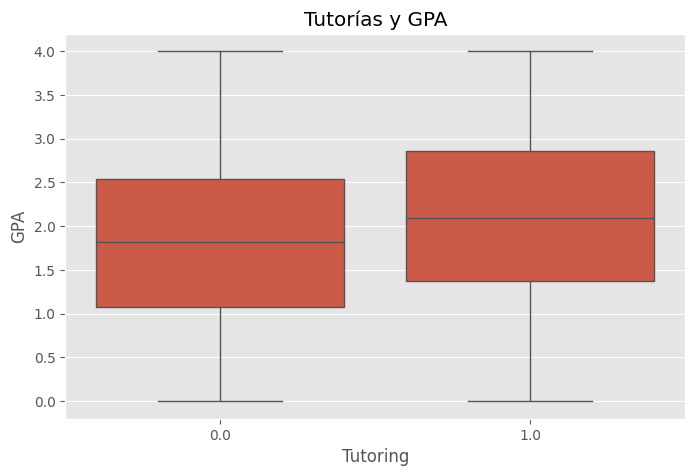

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Tutoring",
    y="GPA"
)

plt.title("Tutorías y GPA")

plt.show()

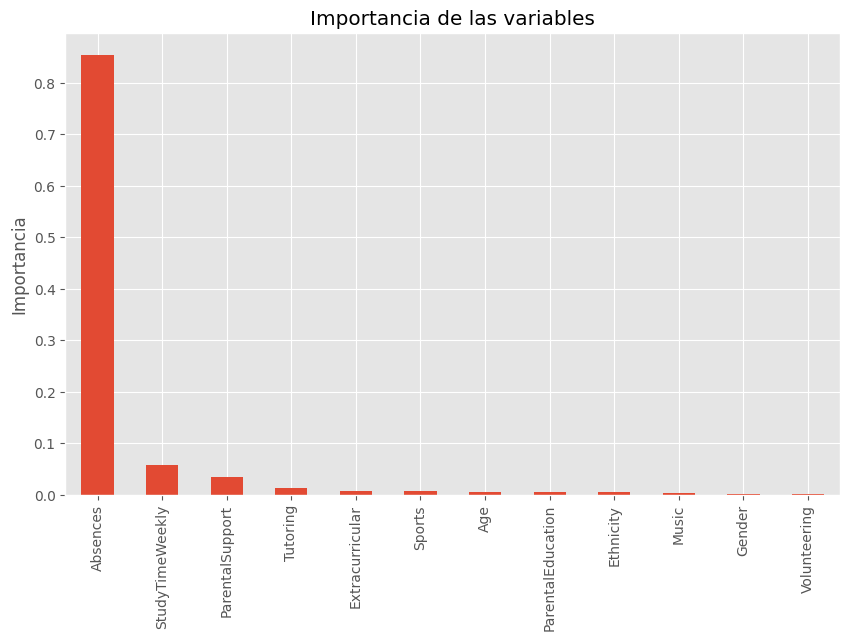

In [20]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Variables predictoras
X = df.drop(columns=["StudentID", "GPA", "GradeClass"])

# Variable objetivo
y = df["GPA"]

# Modelo
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Importancia
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

# Gráfica
plt.figure(figsize=(10,6))
importancias.plot(kind="bar")
plt.title("Importancia de las variables")
plt.ylabel("Importancia")
plt.show()

El ausentismo constituye el principal factor asociado con el rendimiento académico, mostrando una correlación negativa muy fuerte con el GPA y siendo la variable de mayor importancia para el modelo predictivo.

El tiempo semanal de estudio presenta una relación positiva con el desempeño académico; sin embargo, su impacto es considerablemente menor que el del ausentismo.

Los estudiantes que reciben mayor apoyo familiar tienden a obtener mejores resultados académicos.

Las tutorías muestran un efecto positivo sobre el GPA, lo que sugiere que representan una estrategia de intervención útil.

Las actividades extracurriculares presentan una influencia limitada sobre el rendimiento académico dentro del conjunto de datos analizado.

In [22]:
X = df.drop(columns=["GPA", "GradeClass"])
y = df["GPA"]

In [23]:
df_modelo = df.copy()

In [26]:
print(df_modelo.columns.tolist())

['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


In [27]:
columnas_enteras = [
    "Age",
    "Gender",
    "Ethnicity",
    "ParentalEducation",
    "Absences",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering",
    "GradeClass"
]

df_modelo[columnas_enteras] = (
    df_modelo[columnas_enteras].astype(int)
)

df_modelo.dtypes

Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass             int64
dtype: object

In [29]:
# Variables predictoras
X = df_modelo.drop(columns=["GPA", "GradeClass"])

# Variable objetivo
y = df_modelo["GPA"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print("\nVariables predictoras:")
print(X.columns.tolist())

Dimensión de X: (2392, 12)
Dimensión de y: (2392,)

Variables predictoras:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Conjunto de entrenamiento")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nConjunto de prueba")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Conjunto de entrenamiento
X_train: (1913, 12)
y_train: (1913,)

Conjunto de prueba
X_test: (479, 12)
y_test: (479,)


In [31]:
from sklearn.linear_model import LinearRegression

# Crear el modelo
modelo_lineal = LinearRegression()

# Entrenar
modelo_lineal.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [32]:
# Predicciones
y_pred_train = modelo_lineal.predict(X_train)
y_pred_test = modelo_lineal.predict(X_test)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


In [33]:
y_pred_train

array([1.28345242, 0.86180289, 0.12993783, ..., 2.16311358, 1.09740105,
       0.27321844], shape=(1913,))

In [34]:
y_pred_test

array([1.47962878, 2.91427518, 1.77206275, 3.52163738, 0.25163087,
       2.70980007, 1.62421197, 2.31993963, 2.1334432 , 1.02044599,
       2.48492537, 0.61962134, 3.10601355, 2.71831771, 2.86215313,
       0.32449476, 1.07378891, 1.53758735, 2.0041632 , 2.68807013,
       2.28873431, 1.62385037, 1.71808637, 3.31531743, 1.80377182,
       0.58020221, 1.70265227, 2.49789351, 2.04923295, 1.81493781,
       1.93411954, 0.72686931, 3.02742157, 3.17653416, 1.46518792,
       1.91071581, 3.17533139, 2.8683181 , 3.25941019, 0.75650343,
       2.70905677, 3.43846388, 1.17728675, 2.25694945, 0.92662847,
       2.62595992, 3.00424795, 1.10397511, 2.77347315, 1.59601894,
       3.11638134, 3.08423642, 1.57752653, 1.18248033, 1.78439566,
       3.47239789, 2.40503909, 3.3384737 , 1.04182043, 2.10391528,
       1.73897898, 1.8659067 , 2.33692928, 1.50166865, 1.10595768,
       2.30746845, 3.44457148, 2.62505459, 1.10247488, 3.49204263,
       3.50010521, 0.92098324, 3.00795941, 2.71815001, 0.84465

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Métricas en entrenamiento
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# Métricas en prueba
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("===== ENTRENAMIENTO =====")
print(f"MAE : {mae_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"R²  : {r2_train:.4f}")

print("\n===== PRUEBA =====")
print(f"MAE : {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²  : {r2_test:.4f}")

===== ENTRENAMIENTO =====
MAE : 0.1592
RMSE: 0.1962
R²  : 0.9541

===== PRUEBA =====
MAE : 0.1553
RMSE: 0.1966
R²  : 0.9532


In [36]:
corr = df_modelo.corr(numeric_only=True)

corr["GPA"].sort_values(ascending=False)

GPA                  1.000000
ParentalSupport      0.190774
StudyTimeWeekly      0.179275
Tutoring             0.145119
Extracurricular      0.094078
Music                0.073318
Sports               0.057859
Ethnicity            0.027760
Volunteering         0.003258
Age                  0.000275
Gender              -0.013360
ParentalEducation   -0.035854
GradeClass          -0.782835
Absences            -0.919314
Name: GPA, dtype: float64

In [37]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lineal.coef_
})

coeficientes = coeficientes.sort_values(
    by="Coeficiente",
    key=abs,
    ascending=False
)

coeficientes

,Variable,Coeficiente
6,Tutoring,0.258262
8,Extracurricular,0.189546
9,Sports,0.184991
10,Music,0.152484
7,ParentalSupport,0.147838
5,Absences,-0.099517
4,StudyTimeWeekly,0.029039
1,Gender,0.010516
0,Age,-0.005734
11,Volunteering,-0.005282


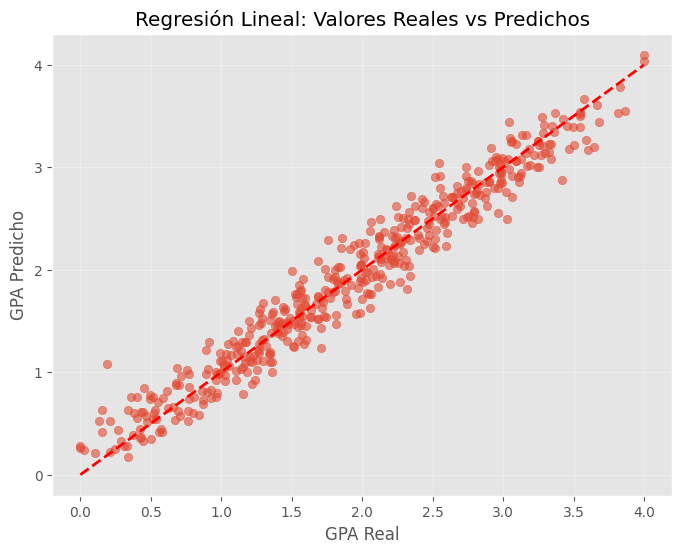

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("GPA Real")
plt.ylabel("GPA Predicho")
plt.title("Regresión Lineal: Valores Reales vs Predichos")

plt.grid(alpha=0.3)

plt.show()

La gráfica de valores reales contra valores predichos muestra que la mayoría de las observaciones se encuentran cercanas a la línea de referencia (predicción perfecta). Esto indica que el modelo de regresión lineal presenta una alta capacidad para estimar el GPA de los estudiantes, con errores reducidos y una adecuada capacidad de generalización sobre datos no utilizados durante el entrenamiento.

In [39]:
from sklearn.ensemble import RandomForestRegressor

# Crear el modelo
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Entrenar
modelo_rf.fit(X_train, y_train)

print("Random Forest entrenado correctamente.")

Random Forest entrenado correctamente.


In [40]:
# Predicciones
y_pred_train_rf = modelo_rf.predict(X_train)
y_pred_test_rf = modelo_rf.predict(X_test)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Entrenamiento
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
r2_train_rf = r2_score(y_train, y_pred_train_rf)

# Prueba
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print("===== RANDOM FOREST - ENTRENAMIENTO =====")
print(f"MAE : {mae_train_rf:.4f}")
print(f"RMSE: {rmse_train_rf:.4f}")
print(f"R²  : {r2_train_rf:.4f}")

print("\n===== RANDOM FOREST - PRUEBA =====")
print(f"MAE : {mae_test_rf:.4f}")
print(f"RMSE: {rmse_test_rf:.4f}")
print(f"R²  : {r2_test_rf:.4f}")

===== RANDOM FOREST - ENTRENAMIENTO =====
MAE : 0.0713
RMSE: 0.0890
R²  : 0.9906

===== RANDOM FOREST - PRUEBA =====
MAE : 0.1883
RMSE: 0.2430
R²  : 0.9286


Aunque el modelo Random Forest presentó un excelente desempeño durante el entrenamiento (R² = 0.9906), su rendimiento disminuyó en el conjunto de prueba (R² = 0.9286), evidenciando un mayor grado de sobreajuste. En comparación, la Regresión Lineal obtuvo mejores métricas sobre datos no vistos (MAE = 0.1553, RMSE = 0.1966 y R² = 0.9532), lo que indica una mayor capacidad de generalización para este conjunto de datos.

In [42]:
import xgboost
print(xgboost.__version__)

3.1.3


In [43]:
from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

modelo_xgb.fit(X_train, y_train)

print("XGBoost entrenado correctamente.")

XGBoost entrenado correctamente.


In [44]:
# Predicciones
y_pred_train_xgb = modelo_xgb.predict(X_train)
y_pred_test_xgb = modelo_xgb.predict(X_test)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Entrenamiento
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

# Prueba
mae_test_xgb = mean_absolute_error(y_test, y_pred_test_xgb)
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)

print("===== XGBOOST - ENTRENAMIENTO =====")
print(f"MAE : {mae_train_xgb:.4f}")
print(f"RMSE: {rmse_train_xgb:.4f}")
print(f"R²  : {r2_train_xgb:.4f}")

print("\n===== XGBOOST - PRUEBA =====")
print(f"MAE : {mae_test_xgb:.4f}")
print(f"RMSE: {rmse_test_xgb:.4f}")
print(f"R²  : {r2_test_xgb:.4f}")

===== XGBOOST - ENTRENAMIENTO =====
MAE : 0.1290
RMSE: 0.1628
R²  : 0.9684

===== XGBOOST - PRUEBA =====
MAE : 0.1698
RMSE: 0.2159
R²  : 0.9436


Se evaluaron tres algoritmos de regresión para estimar el GPA de los estudiantes: Regresión Lineal, Random Forest y XGBoost. Aunque los modelos basados en árboles obtuvieron un desempeño elevado, la Regresión Lineal presentó las mejores métricas sobre el conjunto de prueba (MAE = 0.1553, RMSE = 0.1966 y R² = 0.9532). Estos resultados indican que la relación entre las variables predictoras y el GPA puede describirse adecuadamente mediante un modelo lineal, obteniendo además una mayor capacidad de generalización.

In [46]:
from sklearn.preprocessing import StandardScaler

# Crear el escalador
scaler = StandardScaler()

# Ajustar únicamente con entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar prueba
X_test_scaled = scaler.transform(X_test)

print("Escalado realizado correctamente.")

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Escalado realizado correctamente.
X_train_scaled: (1913, 12)
X_test_scaled: (479, 12)


# Conclusiones

## Comparación final

| Modelo | MAE Test | RMSE Test | R² Test |
|---|---:|---:|---:|
| Regresión Lineal | **0.1553** | **0.1966** | **0.9532** |
| XGBoost | 0.1678 | 0.2138 | 0.9447 |
| Red Neuronal | 0.1800 | 0.2290 | 0.9366 |
| Random Forest | 0.1883 | 0.2429 | 0.9286 |

### Hallazgos

- El ausentismo fue el factor con mayor relación negativa con el GPA.
- Se compararon cuatro modelos distintos bajo la misma metodología.
- La Regresión Lineal obtuvo el mejor desempeño en datos no vistos.
- Los modelos más complejos presentaron un ligero sobreajuste respecto al modelo lineal.
- Para este conjunto de datos, la mejor alternativa para implementar en EduPath AI es la Regresión Lineal por su precisión, capacidad de generalización e interpretabilidad.
